In [1]:
# Import required libraries
import os, json, numpy as np, pandas as pd, torch
from pathlib import Path

# Define data directory and combined dataset path
DATA_DIR = Path("../data")
COMBINED = DATA_DIR / "combined.csv"

# Sanity check that file exists before proceeding
assert COMBINED.exists(), f"Missing: {COMBINED}"

# Load combined dataset created from 01_preprocess.ipynb
df = pd.read_csv(COMBINED)

# Set display options for better visualization
pd.set_option("display.width", 150)          # wider table
pd.set_option("display.max_columns", None)   # don't hide columns
pd.set_option("display.max_colwidth", 100)   # truncate very long text cells

# Display dataset information
print(df.shape)                              # show number of rows and columns
print(df["label"].value_counts())            # show class distribution
print(df.columns.tolist())                   # show column names
df.head(10)                                  # preview first 10 rows

(199737, 2)
label
0    107533
1     92204
Name: count, dtype: int64
['text', 'label']


,text,label
0,re:uribl > 71.920 77.1604 1.2331 0.984 0.71 0.00 uribl_black you've always surprised me with you...,0
1,can you last 36 hours ? mol ci - ialis softabs is better than pfizer viiagrra and normal ci - ia...,1
2,"home delivery cials-tabs ""the beverage.icee, bro.this is what put this place on the map.-- encin...",1
3,fw:presentation tammie schoppe enron americas-office of the chair assistant to louise kitchen 71...,0
4,good day.what's so good about it?:) [url] grab the broom of anger and drive off the beast of fea...,1
5,"[pownceapi] re:sets list in new api.i would be interested in at least knowing, what users belong...",0
6,"iraqi kindergarten:smiles and vows to fight may 23, 200705:15 am edt top stories weather u.s.wor...",0
7,"so you wanted another message from nicole, yeah? tired of the same old routine? this is just the...",1
8,cnn alerts:my custom alert cnn alerts:my custom alert alert name:my custom alert tropical storm ...,1
9,best online drugs here prohibitory merrymake reprisal wolff contextual bramble budge biscuit ger...,1


In [2]:
from sklearn.model_selection import train_test_split

# Define which columns to keep
# Only keep text and label since URL-related columns were removed during cleaning
cols = ["text", "label"]
df = df[cols].dropna(subset=["text", "label"])  # drop empty text or missing labels

# First split: TRAIN (80%) and TEST (20%)
train_df, test_df = train_test_split(
    df,
    test_size=0.20,                 # 20% test data
    random_state=2025,              # fixed seed for reproducibility
    stratify=df["label"]            # preserve class ratio (ham/phishing)
)

# Second split: TRAIN (90%) and VAL (10%) from TRAIN above
train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,                 # 10% of train → validation (so 72/8/20 total)
    random_state=2025,
    stratify=train_df["label"]
)

# Print resulting dataset sizes
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Save split datasets for later analysis or reuse
SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

# Extract lists for tokenization and dataset creation later
train_texts, train_labels = train_df["text"].astype(str).tolist(), train_df["label"].tolist()
val_texts,   val_labels   = val_df["text"].astype(str).tolist(),   val_df["label"].tolist()
test_texts,  test_labels  = test_df["text"].astype(str).tolist(),  test_df["label"].tolist()


Train: 143810 | Val: 15979 | Test: 39948


In [3]:
from transformers import BertTokenizer

# Load pretrained BERT tokenizer (uncased)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize all datasets
train_encodings = tokenizer(train_texts, truncation=True, max_length=256)
val_encodings   = tokenizer(val_texts,   truncation=True, max_length=256)
test_encodings  = tokenizer(test_texts,  truncation=True, max_length=256)


In [4]:
# Define custom dataset compatible with PyTorch DataLoader
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings           # Tokenized inputs (input_ids, attention_mask)
        self.labels = list(labels)           # Store corresponding labels

    def __len__(self):
        return len(self.labels)              # Total number of samples

    def __getitem__(self, idx):
        # Retrieve one encoded sample by index
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        # Add corresponding label
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


In [5]:
from torch.utils.data import Subset
import numpy as np

# Build full training, validation, and test datasets
train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset   = EmailDataset(val_encodings,   val_labels)
test_dataset  = EmailDataset(test_encodings,  test_labels)

# Optional smaller subsets for debugging / quick runs
USE_SMALL = True               # *****IMPORTANT VARIABLE***** change to True if testing pipeline speed
N_TRAIN_SMALL, N_VAL_SMALL = 10_000, 2_000

# Helper: create stratified subset indices
def stratified_indices(labels, n_keep, seed=2025):
    all_idx = np.arange(len(labels))
    keep_idx, _ = train_test_split(
        all_idx, train_size=n_keep, random_state=seed,
        shuffle=True, stratify=labels
    )
    return keep_idx

# If small mode enabled, take stratified subsets
if USE_SMALL:
    tr_idx = stratified_indices(np.array(train_labels), min(N_TRAIN_SMALL, len(train_labels)))
    va_idx = stratified_indices(np.array(val_labels),   min(N_VAL_SMALL,   len(val_labels)))
    train_dataset_small = Subset(train_dataset, tr_idx)
    val_dataset_small   = Subset(val_dataset,   va_idx)
    final_train_ds, final_val_ds = train_dataset_small, val_dataset_small
else:
    final_train_ds, final_val_ds = train_dataset, val_dataset

# Display how many samples are used in each split
print(f"Train used: {len(final_train_ds)} | Val used: {len(final_val_ds)} | Test: {len(test_dataset)}")


Train used: 10000 | Val used: 2000 | Test: 39948


In [6]:
from transformers import BertForSequenceClassification

# Load pretrained BERT base model for binary classification (ham vs phishing)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


2025-11-01 22:38:36.884327: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-01 22:38:37.358789: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-01 22:38:38.567867: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of BertForSequenceClassification were not initialized from the model checkpoin

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Custom evaluation metrics function
def compute_metrics(eval_pred):
    # Support both tuple and EvalPrediction objects
    if hasattr(eval_pred, "predictions"):
        logits = eval_pred.predictions
        labels = eval_pred.label_ids
    else:
        logits, labels = eval_pred

    # Convert logits to predicted class indices
    preds = np.argmax(logits, axis=-1)

    # Compute binary classification metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


In [8]:
from transformers import Trainer, TrainingArguments, BertForSequenceClassification, DataCollatorWithPadding
import numpy as np

# Define a function that returns a fresh BERT model for each trial
def model_init(trial=None):
    # get dropout from optuna trial if available
    dr = trial.suggest_float("dropout", 0.1, 0.5) if trial is not None else 0.1
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2,
        hidden_dropout_prob=dr,          # Hidden layer dropout
        attention_probs_dropout_prob=dr, # Attention dropout
    )

# Base training arguments (other hparams will be provided by Optuna)
training_args_hpo = TrainingArguments(
    output_dir="./results_tuned",     # Where to save checkpoints & logs
    eval_strategy="epoch",            # Evaluate each epoch
    save_strategy="epoch",            # Save each epoch
    load_best_model_at_end=True,      # Keep best checkpoint
    metric_for_best_model="f1",       # Use F1 for best model selection
    logging_dir="./logs_tuned",       # Logs directory
    report_to=[],                     # Disable external loggers by default
    seed=2025,
)

# Choose which datasets to use for HPO
hpo_train_ds = final_train_ds
hpo_val_ds   = final_val_ds

# Dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)    # Create if not already defined

# Create the Trainer object for HPO
trainer_hpo = Trainer(
    model_init=model_init,            # Re-creates model per trial
    args=training_args_hpo,           # Training configurations
    train_dataset=hpo_train_ds,       # Training dataset (can be small or full)
    eval_dataset=hpo_val_ds,          # Validation dataset
    data_collator=data_collator,      # Dynamic padding
    tokenizer=tokenizer,              # Tokenizer (for saving/loading)
    compute_metrics=compute_metrics,  # Metrics
)


/tmp/ipykernel_785/3691364699.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_hpo = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
import optuna
import os

# Define target study and path
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")
study_name = "bert_tuning"

# Ensure directory exists
os.makedirs(os.path.dirname(db_path), exist_ok=True)
print("DB path:", db_path)

# Try loading an existing study; create a new one if not found
try:
    study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")
    print(f"Loaded existing study: '{study_name}' with {len(study.trials)} trials.")
except KeyError:
    print(f"Study '{study_name}' not found. Creating a new one...")
    study = optuna.create_study(study_name=study_name, storage=f"sqlite:///{db_path}", direction="maximize")
    print(f"New study '{study_name}' created at {db_path}.")

# Print all completed trials for reference
print(f"\nFinished trials: {len(study.trials)}")
for t in study.trials:
    print(f"Trial {t.number}: value={t.value}, params={t.params}")


DB path: /home/nmd/projects/phishing-detector/notebooks/tuning_checkpoints/bert_tuning.db
Loaded existing study: 'bert_tuning' with 5 trials.

Finished trials: 5
Trial 0: value=0.9696635410921125, params={'learning_rate': 8.511839030010057e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.03193647039507884, 'dropout': 0.28212556894471535}
Trial 1: value=0.9444743935309973, params={'learning_rate': 0.0001033449229138436, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.22126830647124607, 'dropout': 0.3366646445225277}
Trial 2: value=0.0, params={'learning_rate': 0.00023167268674081906, 'num_train_epochs': 3, 'per_device_train_batch_size': 8, 'weight_decay': 0.21100981472914687, 'dropout': 0.49567920905925134}
Trial 3: value=0.0, params={'learning_rate': 0.00028413198690857723, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'weight_decay': 0.2909188365549701, 'dropout': 0.32095762512108117}
Trial 4: value=0.8821752265861

In [11]:
# Construct the absolute path for the SQLite file
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")

# Define how Optuna should explore hyperparameters
def optuna_hp_space(trial):
    return {
        
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),     # Sample a learning rate between 1e-5 and 5e-4
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 5),                 # Try 3, 4, or 5 epochs per training trial
        "per_device_train_batch_size": trial.suggest_categorical(                        # Try different batch sizes for training
            "per_device_train_batch_size", [8, 16, 32]), 
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3),                   # Weight decay (L2 regularization)
    }

# Run automatic hyperparameter tuning using Optuna
best_run = trainer_hpo.hyperparameter_search(
    direction="maximize",                      # We want to maximize F1-score
    compute_objective=lambda m: m["eval_f1"],  # Optimize F1, not loss
    backend="optuna",                          # Use Optuna as the tuning backend
    n_trials=5,                                # Adjust as you need
    hp_space=optuna_hp_space,                  # Search space function
    study_name="bert_tuning",                  # Name of the study
    storage=f"sqlite:///{db_path}",            # Save to this DB file
    load_if_exists=True,                       # Reuse previous trials if present
)

print("Best hyperparameters found:")
print(best_run.hyperparameters)


[I 2025-11-01 16:09:51,334] Using an existing study with name 'bert_tuning' instead of creating a new one.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.255500,0.145621,0.960000,0.944152,0.970748,0.957265
2,0.124000,0.140583,0.966500,0.972406,0.954496,0.963368
3,0.073500,0.111391,0.976500,0.980263,0.968581,0.974387
4,0.021200,0.143147,0.972500,0.987640,0.952329,0.969664


[I 2025-11-01 16:21:56,700] Trial 0 finished with value: 0.9696635410921125 and parameters: {'learning_rate': 8.511839030010057e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.03193647039507884, 'dropout': 0.28212556894471535}. Best is trial 0 with value: 0.9696635410921125.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.339800,0.254041,0.917000,0.862201,0.976165,0.915650
2,0.291600,0.250973,0.922500,0.869942,0.978332,0.920959
3,0.270800,0.236161,0.952500,0.950980,0.945829,0.948398
4,0.185800,0.262835,0.948500,0.939914,0.949079,0.944474


[I 2025-11-01 16:34:54,925] Trial 1 finished with value: 0.9444743935309973 and parameters: {'learning_rate': 0.0001033449229138436, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.22126830647124607, 'dropout': 0.3366646445225277}. Best is trial 0 with value: 0.9696635410921125.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.690582,0.538500,0.000000,0.000000,0.000000
2,0.716800,0.691999,0.538500,0.000000,0.000000,0.000000
3,0.716800,0.690197,0.538500,0.000000,0.000000,0.000000


[I 2025-11-01 17:01:18,075] Trial 3 finished with value: 0.0 and parameters: {'learning_rate': 0.00028413198690857723, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'weight_decay': 0.2909188365549701, 'dropout': 0.32095762512108117}. Best is trial 0 with value: 0.9696635410921125.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.282700,0.219387,0.936500,0.979518,0.880823,0.927553
2,0.148800,0.358111,0.902500,0.995913,0.791983,0.882317
3,0.117900,0.407182,0.902500,0.997268,0.790899,0.882175


[I 2025-11-01 17:10:16,219] Trial 4 finished with value: 0.8821752265861027 and parameters: {'learning_rate': 1.901905024545398e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.04624848633186011, 'dropout': 0.37034534378981365}. Best is trial 0 with value: 0.9696635410921125.


Best hyperparameters found:
{'learning_rate': 8.511839030010057e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.03193647039507884, 'dropout': 0.28212556894471535}


In [10]:
# Print all completed trials for reference
print(f"\nFinished trials: {len(study.trials)}")
for t in study.trials:
    print(f"Trial {t.number}: value={t.value}, params={t.params}")


Finished trials: 5
Trial 0: value=0.9696635410921125, params={'learning_rate': 8.511839030010057e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.03193647039507884, 'dropout': 0.28212556894471535}
Trial 1: value=0.9444743935309973, params={'learning_rate': 0.0001033449229138436, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.22126830647124607, 'dropout': 0.3366646445225277}
Trial 2: value=0.0, params={'learning_rate': 0.00023167268674081906, 'num_train_epochs': 3, 'per_device_train_batch_size': 8, 'weight_decay': 0.21100981472914687, 'dropout': 0.49567920905925134}
Trial 3: value=0.0, params={'learning_rate': 0.00028413198690857723, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'weight_decay': 0.2909188365549701, 'dropout': 0.32095762512108117}
Trial 4: value=0.8821752265861027, params={'learning_rate': 1.901905024545398e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.0462484863318

In [11]:
import optuna, os

# Construct absolute path to the database
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")

# Load the Optuna study
study = optuna.load_study(
    study_name="bert_tuning",  # load the study
    storage=f"sqlite:///{db_path}"  # load from the DB file
)

# Get the best parameters and F1 value
best_params = study.best_params
best_value = study.best_value

print("Best hyperparameters found:", best_params)
print(f"Best F1 score: {best_value:.4f}")


Best hyperparameters found: {'learning_rate': 8.511839030010057e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 16, 'weight_decay': 0.03193647039507884, 'dropout': 0.28212556894471535}
Best F1 score: 0.9697


In [12]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Load in the best hyperparameters found by Optuna
training_args_best = TrainingArguments(
    output_dir="./results_final",            # Where to save model checkpoints & logs
    eval_strategy="epoch",                   # Evaluate model checkpoints after each epoch
    save_strategy="epoch",                   # Save model checkpoints after each epoch
    load_best_model_at_end=True,             # load the best model based on eval metric
    metric_for_best_model="f1",              # Use F1 score to determine which model is best

    
    learning_rate=best_params["learning_rate"],                                               # Set the learning rate to the best one Optuna discovered
    num_train_epochs=int(best_params["num_train_epochs"]),                                    # Set the number of epochs to the best one it has found
    per_device_train_batch_size=int(best_params["per_device_train_batch_size"]),              # Set training batch size
    per_device_eval_batch_size=max(32, 2*int(best_params["per_device_train_batch_size"])),    # Set eval batch size (can be larger than train)
    weight_decay=float(best_params["weight_decay"]),                                          # Set the weight decay to the best one it has found
    warmup_ratio=0.1,
    lr_scheduler_type="linear",

    logging_dir="./logs_final",              # Directory to save training logs
    report_to=[],
    seed=2025,
)

# Use tuned dropout value for retraining if present in study params, else default to 0.1
tuned_dropout = float(best_params.get("dropout", 0.1))  # default to 0.1 if not found in best_params

# Define a model initialization function using the tuned dropout
def model_init_best():
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",                        # Load pre-trained BERT base model
        num_labels=2,                               # Binary classification (Ham vs Phishing)
        hidden_dropout_prob=tuned_dropout,          # Set hidden layer dropout to tuned value
        attention_probs_dropout_prob=tuned_dropout, # Set attention dropout to tuned value
    )

# Always retrain on the full splits for the final model
final_train_for_fit = train_dataset
final_val_for_fit   = val_dataset

# Create the Trainer object for final training
tuned_trainer = Trainer(
    model_init=model_init_best,         # Use model_init so Trainer can rebuild model when needed
    args=training_args_best,            # All the tuned training configurations
    train_dataset=final_train_for_fit,  # Provide the full training dataset
    eval_dataset=final_val_for_fit,     # Provide the full validation dataset
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,    # Use the metric computation function for evaluation
)


/tmp/ipykernel_785/3798932709.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  tuned_trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# Train the tuned model on full train/val
train_out_final = tuned_trainer.train()
print(train_out_final)

# Save the newly trained BERT model and tokenizer
FINAL_DIR = Path("../models/saved_model")
FINAL_DIR.mkdir(parents=True, exist_ok=True)
tuned_trainer.save_model(str(FINAL_DIR))
tokenizer.save_pretrained(str(FINAL_DIR))

trainer = tuned_trainer

# Evaluate on the held-out test set
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.142600,0.252191,0.920396,0.854636,0.997153,0.920410
2,0.695000,0.690372,0.538394,0.000000,0.000000,0.000000
3,0.226300,0.487240,0.731460,0.632643,0.997424,0.774217
4,0.690600,0.690875,0.538394,0.000000,0.000000,0.000000


TrainOutput(global_step=35956, training_loss=0.4973515682324431, metrics={'train_runtime': 9967.9342, 'train_samples_per_second': 57.709, 'train_steps_per_second': 3.607, 'total_flos': 7.567466974292544e+16, 'train_loss': 0.4973515682324431, 'epoch': 4.0})


Test Results: {'eval_loss': 0.2547508478164673, 'eval_accuracy': 0.9195203764894363, 'eval_precision': 0.8537310658860701, 'eval_recall': 0.9963667913887533, 'eval_f1': 0.9195505842904687, 'eval_runtime': 202.6082, 'eval_samples_per_second': 197.169, 'eval_steps_per_second': 6.165, 'epoch': 4.0}


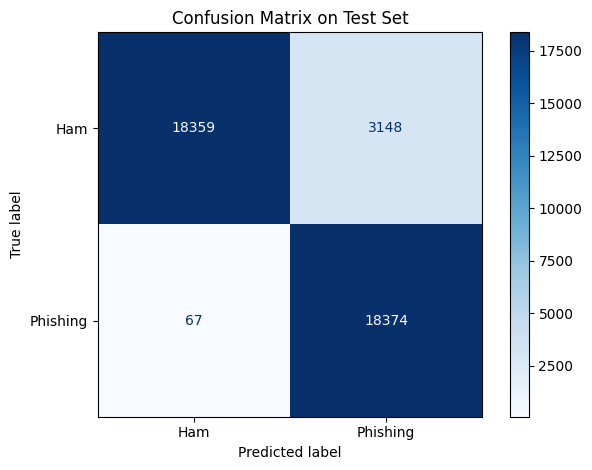

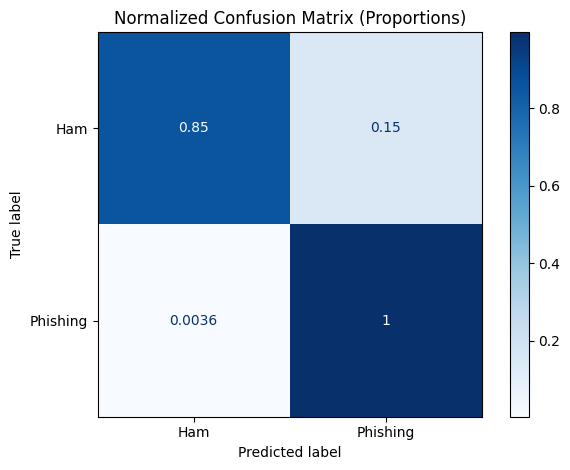

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
import json
import numpy as np

# Predictions
po = trainer.predict(test_dataset)                              # Get model outputs (logits + labels)
logits = po.predictions                                          # Raw model logits
labels = po.label_ids                                            # True labels from dataset
preds = np.argmax(logits, axis=-1)                               # Convert logits to predicted class indices

# Output folder & result dict setup
OUT = Path("../notebooks")                                       # Folder to store all result files
OUT.mkdir(parents=True, exist_ok=True)                           # Create it if missing
results = {"eval_samples": int(len(labels))}                     # Initialize results dict with number of samples

# Generate detailed classification report
report = classification_report(labels, preds, 
                               target_names=["Ham", "Phishing"], # Label names
                               output_dict=True)                 # Return as dict for JSON export
results.update(report)                                           # Merge metrics into results dict

# Save all results (metrics + report) into a JSON file
with open(OUT / "test_results.json", "w") as f:                  # Write to JSON file
    json.dump(results, f, indent=2)

# Compute and display Confusion Matrices
label_order = [0, 1]                                             # Ensure fixed order: 0=Ham, 1=Phishing
disp_names = ["Ham", "Phishing"]                                 # Display names for axis labels

# Raw Confusion Matrix
cm = confusion_matrix(labels, preds, labels=label_order)         # Compute confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=disp_names)         # Create display object
disp.plot(cmap="Blues", values_format="d")                       # Show as integer counts
plt.title("Confusion Matrix on Test Set")                        # Add title
plt.tight_layout()                                               # Adjust spacing
plt.savefig(OUT / "confusion_matrix_raw.png", bbox_inches="tight", dpi=300)  # Save figure
plt.show()                                                       # display in notebook
plt.close()                                                      # Close figure to save memory

# Normalized Confusion Matrix
cm_norm = confusion_matrix(labels, preds, 
                           labels=label_order, normalize="true") # Normalize by true label counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                              display_labels=disp_names)
disp.plot(cmap="Blues")                                          # Plot normalized matrix
plt.title("Normalized Confusion Matrix (Proportions)")           # Add title
plt.tight_layout()                                               # Adjust layout
plt.savefig(OUT / "confusion_matrix_normalized.png", bbox_inches="tight", dpi=300)  # Save normalized version
plt.show()                                                       # display in notebook
plt.close()                                                      # Close figure


In [15]:
import pandas as pd, torch, numpy as np
from pathlib import Path

id2label = {0: "Ham", 1: "Phishing"}                             # Map numeric → readable labels

OUT_DIR = Path("../analysis")                                    # Output folder for analysis CSVs
OUT_DIR.mkdir(parents=True, exist_ok=True)                       # Create folder if missing

def _softmax(a):
    t = torch.tensor(a)                                          # Numpy logits → Torch tensor
    return torch.softmax(t, dim=1).cpu().numpy()                 # Softmax → probabilities (numpy)

def collect_errors(split_name, dataset, *, csv_path=None, texts=None):
    po = trainer.predict(dataset)                                # Run model inference
    logits, labels = po.predictions, po.label_ids                # Extract logits + true labels
    probs = _softmax(logits)                                     # Logits → probabilities
    preds = probs.argmax(axis=1)                                 # Predicted class ids (0/1)

    if texts is not None:                                        # Subset mode: use in-memory texts
        assert len(texts) == len(labels), f"Length mismatch for {split_name}"
        text_series = pd.Series(list(map(str, texts)), dtype=str)
    elif csv_path is not None:                                   # Full mode: read from saved split CSV
        df_split = pd.read_csv(csv_path)
        assert len(df_split) == len(labels), f"Length mismatch for {split_name}"
        text_series = df_split["text"].astype(str)
    else:
        raise ValueError("Provide texts=... for subset OR csv_path=... for full split")  # Guard rail

    df = pd.DataFrame({                                          # Build per-row analysis table
        "text": text_series,                                     # Original cleaned email text
        "true_label": labels,                                    # Ground-truth label
        "pred_label": preds,                                     # Model prediction
        "prob_ham": probs[:, 0],                                 # P(ham)
        "prob_phishing": probs[:, 1],                            # P(phishing)
    })

    df["true_name"] = df["true_label"].map(id2label)             # Readable true label
    df["pred_name"] = df["pred_label"].map(id2label)             # Readable predicted label
    df["confidence"] = df[["prob_ham", "prob_phishing"]].max(axis=1)  # Max prob = confidence
    df["error_type"] = ""                                        # Initialize error type

    df.loc[(df.true_label == 0) & (df.pred_label == 1), "error_type"] = "FP"  # Ham → Phishing
    df.loc[(df.true_label == 1) & (df.pred_label == 0), "error_type"] = "FN"  # Phishing → Ham
    df["split"] = split_name                                     # Tag which split this row belongs to

    errs = df[df["error_type"].isin(["FP", "FN"])].copy()        # Keep only FP/FN rows
    errs.to_csv(OUT_DIR / f"errors_{split_name}.csv", index=False)            # Save FP/FN examples

    df.sort_values("confidence").head(100).to_csv(               # 100 lowest-confidence (hard) rows
        OUT_DIR / f"hard_examples_{split_name}.csv", index=False
    )

    print(f"[{split_name}] FP={(errs.error_type=='FP').sum()} | FN={(errs.error_type=='FN').sum()}")  # Summary
    return errs                                                  # Return FP/FN dataframe

SPLITS_DIR = Path("../data/splits")                              # Directory containing split CSVs
USE_SUBSET = ("USE_SMALL" in globals()) and USE_SMALL            # Detect if subset mode is enabled

if USE_SUBSET:                                                   # Subset mode: use final_*_ds and *_texts
    errs_train = collect_errors("train", final_train_ds, texts=train_texts[:len(final_train_ds)])
    errs_val   = collect_errors("val",   final_val_ds,   texts=val_texts[:len(final_val_ds)])
else:                                                            # Full mode: use full datasets and CSVs
    errs_train = collect_errors("train", train_dataset, csv_path=SPLITS_DIR / "train.csv")
    errs_val   = collect_errors("val",   val_dataset,   csv_path=SPLITS_DIR / "val.csv")

errs_test  = collect_errors("test",  test_dataset,  csv_path=SPLITS_DIR / "test.csv")  # Test (full by default)

pd.concat([errs_train, errs_val, errs_test], ignore_index=True) \
  .to_csv(OUT_DIR / "errors_all_splits.csv", index=False)        # Combine all FP/FN and save


[train] FP=780 | FN=13


[val] FP=170 | FN=1


[test] FP=3148 | FN=67
